In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/13
    print("準備完了！このまま下のセルを実行できます。")

# 第13章 グラフニューラルネットワーク (Graph Neural Networks)
## 13.3 一般化グラフネットワーク (General Graph Networks)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第13章「グラフニューラルネットワーク」第13.3節「一般化グラフネットワーク (General Graph Networks)」の全6小節（13.3.1 〜 13.3.6）の完全な理論解説、数学的定式化（式 13.24 〜 式 13.41、Algorithm 13.2）、教科書図版（Figure 13.5 全1枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **13.3.1 グラフアテンションネットワーク (Graph Attention Networks, 式 13.24 〜 13.28)**
   - アテンション係数 $A_{nm}$ によるメッセージ重み付け集約（式 13.24）
   - 双線形形式によるアテンション（式 13.27）
   - MLP によるペア結合アテンション（式 13.28）
   - マルチヘッド・グラフアテンションとトランスフォーマー (Transformer Encoder) との関係
3. **13.3.2 エッジ埋め込み (Edge Embeddings, 式 13.29 〜 13.31)**
   - 隠れエッジ埋め込みベクトル $\mathbf{e}_{nm}^{(l)}$ の導入
   - エッジ更新（式 13.29）: $\mathbf{e}_{nm}^{(l+1)} = \text{Update}_{\text{edge}}(\mathbf{e}_{nm}^{(l)}, \mathbf{h}_n^{(l)}, \mathbf{h}_m^{(l)})$
   - エッジからのノード集約（式 13.30）とノード更新（式 13.31）
4. **13.3.3 グラフ埋め込みと一般化MPNN (Algorithm 13.2, Figure 13.5, 式 13.32 〜 13.35)**
   - 大域グラフ埋め込み $\mathbf{g}^{(l)}$ を統合した統一枠組み (Battaglia et al., 2018)
   - 4段階メッセージパッシング更新方程式（式 13.32 〜 13.35）
   - 教科書 図 13.5 の完全再現：
     - (a) エッジ更新 (Edge updates)
     - (b) ノード更新 (Node updates)
     - (c) 大域グラフ更新 (Global graph updates)
5. **13.3.4 過剰平滑化 (Over-smoothing, 式 13.36 〜 13.37)**
   - 層の深化に伴うノード表現の均一化とディリクレエネルギー $E(H) \to 0$
   - 残差接続による緩和（式 13.36）: $\mathbf{h}_n^{(l+1)} = \text{Update} + \mathbf{h}_n^{(l)}$
   - Jumping Knowledge (JK-Net) による全中間層結合（式 13.37）
6. **13.3.5 正則化 (Regularization)**
   - 層間重み共有 (Weight sharing)
   - ノードドロップアウト (Node dropout)
   - エッジドロップアウト (DropEdge, Rong et al. 2020)
7. **13.3.6 幾何学的深層学習 (Geometric Deep Learning, EGNN, 式 13.38 〜 13.41)**
   - 3次元空間座標 $\mathbf{r}_n^{(l)} \in \mathbb{R}^3$ と $E(3)$ 対称性（並進・回転・鏡映）
   - 不変二乗距離 $\|\mathbf{r}_n - \mathbf{r}_m\|^2$ を用いたエッジ更新（式 13.38）
   - 同変座標更新（式 13.39）: $\mathbf{r}_n^{(l+1)} = \mathbf{r}_n^{(l)} + C \sum (\mathbf{r}_n - \mathbf{r}_m) \phi(\mathbf{e}_{nm})$
   - 3次元回転・並進・鏡映に対する厳密な数値同変性検証
8. **まとめと第13章演習問題への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent if Path.cwd().name == "13" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.machine_learning_on_graphs import Graph, build_permutation_matrix
from common.neural_message_passing import relu, sigmoid, softmax
from common.general_graph_networks import (
    compute_attention_bilinear,
    compute_attention_mlp,
    GATLayer,
    MultiHeadGATLayer,
    EdgeNodeMPNNLayer,
    GeneralMPNNLayer,
    compute_dirichlet_energy,
    compute_mean_pairwise_distance,
    jumping_knowledge_pool,
    apply_drop_edge,
    apply_node_dropout,
    EGNNLayer,
    check_egnn_equivariance,
    generate_figure_13_5,
)

setup_style()
print("Common general_graph_networks modules successfully loaded.")


Common general_graph_networks modules successfully loaded.


---
## 13.3.1 グラフアテンションネットワーク (Graph Attention Networks)

### 1. アテンション重み付け集約 (Eqs 13.24 〜 13.26)
前節 13.2 で学んだ和集約や平均集約は、すべての近傍ノードを一様または次数に応じた固定の重みで集約していました。しかし、トランスフォーマー（第12章）の自己アテンション機構と同様に、どの近傍が現在重要であるかは入力データそのものに依存して動的に決定されるべきです。

グラフアテンションネットワーク (GAT, Veličković et al., 2017) では、近傍ノードからのメッセージにアテンション係数 $A_{nm}$ を乗じて集約します（式 13.24）：

$$
\mathbf{z}_n^{(l)} = \sum_{m \in \mathcal{N}(n)} A_{nm} \mathbf{h}_m^{(l)} \tag{13.24}
$$

ここで、アテンション係数は非負であり、各ノードの近傍にわたって和が 1 となる確率分布（ソフトマックス出力）を形成します（式 13.25, 13.26）：

$$
A_{nm} \ge 0 \tag{13.25}
$$
$$
\sum_{m \in \mathcal{N}(n)} A_{nm} = 1 \tag{13.26}
$$

### 2. アテンション係数の計算メカニズム
1. **双線形形式 (Bilinear form)** (式 13.27):
   $$
   A_{nm} = \frac{\exp\left( (\mathbf{h}_n^{(l)})^T W \mathbf{h}_m^{(l)} \right)}{\sum_{m' \in \mathcal{N}(n)} \exp\left( (\mathbf{h}_n^{(l)})^T W \mathbf{h}_{m'}^{(l)} \right)} \tag{13.27}
   $$

2. **MLP 形式** (式 13.28):
   $$
   A_{nm} = \frac{\exp\left( \text{MLP}(\mathbf{h}_n^{(l)}, \mathbf{h}_m^{(l)}) \right)}{\sum_{m' \in \mathcal{N}(n)} \exp\left( \text{MLP}(\mathbf{h}_n^{(l)}, \mathbf{h}_{m'}^{(l)}) \right)} \tag{13.28}
   $$

3. **マルチヘッド化 (Multi-Head Attention)**:
   $H$ 個の独立なヘッドで計算した表現を結合し、線形射影します。完全グラフにおいては、GAT は標準的なトランスフォーマーエンコーダと等価になります。


In [2]:
# GAT レイヤーとマルチヘッドアテンションの実行と検証
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
rng = np.random.RandomState(42)
X = rng.randn(4, 6)
graph = Graph(num_nodes=4, edges=edges, node_features=X, is_directed=False)

# 単一ヘッド GAT
gat_single = GATLayer(in_dim=6, out_dim=8, attn_type="bilinear", seed=42)
H_gat_single = gat_single.forward(graph)

# マルチヘッド GAT (4ヘッド, 各ヘッド 4次元 -> 結合後 16次元 -> 8次元へ射影)
gat_multi = MultiHeadGATLayer(in_dim=6, out_dim_per_head=4, num_heads=4, seed=42)
H_gat_multi = gat_multi.forward(graph)

print("=== GAT 出力形状と数値検証 ===")
print(f"入力特徴量形状: {X.shape}")
print(f"単一ヘッド GAT 出力形状: {H_gat_single.shape}")
print(f"4ヘッド GAT 出力形状:     {H_gat_multi.shape}")

# 置換行列によるノード順序置換に対する同変性検証
perm = [3, 1, 0, 2]
P = build_permutation_matrix(perm)
A_perm = P @ graph.A @ P.T
X_perm = P @ X
edges_perm = []
for i in range(4):
    for j in range(4):
        if A_perm[i, j] > 0 and i < j:
            edges_perm.append((i, j))
graph_perm = Graph(num_nodes=4, edges=edges_perm, node_features=X_perm, is_directed=False)

H_perm = gat_single.forward(graph_perm)
diff = np.max(np.abs(H_perm - P @ H_gat_single))
print(f"置換同変性誤差: {diff:.6e}")
assert diff < 1e-5, "GAT must be permutation equivariant"
print("GAT の置換同変性が厳密に確認されました。")


=== GAT 出力形状と数値検証 ===
入力特徴量形状: (4, 6)
単一ヘッド GAT 出力形状: (4, 8)
4ヘッド GAT 出力形状:     (4, 4)
置換同変性誤差: 5.551115e-17
GAT の置換同変性が厳密に確認されました。


---
## 13.3.2 エッジ埋め込み (Edge Embeddings)

ノードに加えてエッジにも隠れ埋め込みベクトル $\mathbf{e}_{nm}^{(l)}$ を保持・更新することで、分子結合の種別（単結合・二重結合）や相互作用の強さを動的に表現できます（式 13.29 〜 13.31）：

1. **エッジ更新** (式 13.29):
   $$
   \mathbf{e}_{nm}^{(l+1)} = \text{Update}_{\text{edge}}\left( \mathbf{e}_{nm}^{(l)}, \mathbf{h}_n^{(l)}, \mathbf{h}_m^{(l)} \right) \tag{13.29}
   $$

2. **ノード集約** (式 13.30):
   $$
   \mathbf{z}_n^{(l+1)} = \text{Aggregate}_{\text{node}}\left( \left\{ \mathbf{e}_{nm}^{(l+1)} : m \in \mathcal{N}(n) \right\} \right) \tag{13.30}
   $$

3. **ノード更新** (式 13.31):
   $$
   \mathbf{h}_n^{(l+1)} = \text{Update}_{\text{node}}\left( \mathbf{h}_n^{(l)}, \mathbf{z}_n^{(l+1)} \right) \tag{13.31}
   $$


In [3]:
# エッジ埋め込みとノード埋め込みの同時更新レイヤーの実行
edge_layer = EdgeNodeMPNNLayer(node_dim=6, edge_dim=3, seed=42)

# 初期エッジ特徴量辞書
E_init = {(u, v): np.ones(3) * 0.5 for u, v in edges}
H_next, E_next = edge_layer.forward(graph, X, E_init)

print("=== エッジ・ノード同時更新の出力 ===")
print(f"更新後ノード埋め込み形状: {H_next.shape}")
print(f"更新後エッジ数: {len(E_next)}")
for (u, v), e_vec in list(E_next.items())[:3]:
    print(f"  エッジ ({u}, {v}) 埋め込み: {e_vec}")


=== エッジ・ノード同時更新の出力 ===
更新後ノード埋め込み形状: (4, 6)
更新後エッジ数: 10
  エッジ (0, 1) 埋め込み: [0. 0. 0.]
  エッジ (1, 0) 埋め込み: [0.9932954  0.80368127 1.05278207]
  エッジ (1, 2) 埋め込み: [0.48244865 0.77066658 0.69233442]


---
## 13.3.3 グラフ埋め込みと一般化MPNN (Algorithm 13.2, Figure 13.5)

### 1. 統一的メッセージパッシング枠組み (Battaglia et al., 2018)
ノード表現 $\mathbf{h}_n^{(l)}$、エッジ表現 $\mathbf{e}_{nm}^{(l)}$ に加え、グラフ全体を表す埋め込みベクトル $\mathbf{g}^{(l)}$ を同時に保持・更新する一般化枠組みを構築します（式 13.32 〜 13.35、Algorithm 13.2）：

$$
\mathbf{e}_{nm}^{(l+1)} = \text{Update}_{\text{edge}}\left( \mathbf{e}_{nm}^{(l)}, \mathbf{h}_n^{(l)}, \mathbf{h}_m^{(l)}, \mathbf{g}^{(l)} \right) \tag{13.32}
$$
$$
\mathbf{z}_n^{(l+1)} = \text{Aggregate}_{\text{node}}\left( \left\{ \mathbf{e}_{nm}^{(l+1)} : m \in \mathcal{N}(n) \right\} \right) \tag{13.33}
$$
$$
\mathbf{h}_n^{(l+1)} = \text{Update}_{\text{node}}\left( \mathbf{h}_n^{(l)}, \mathbf{z}_n^{(l+1)}, \mathbf{g}^{(l)} \right) \tag{13.34}
$$
$$
\mathbf{g}^{(l+1)} = \text{Update}_{\text{graph}}\left( \mathbf{g}^{(l)}, \left\{ \mathbf{h}_n^{(l+1)} : n \in \mathcal{V} \right\}, \left\{ \mathbf{e}_{nm}^{(l+1)} : (n, m) \in \mathcal{E} \right\} \right) \tag{13.35}
$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/13/result/fig_13_5_general_graph_updates.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_13_5_general_graph_updates.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/13/result/Figure_13_5.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_13_5.png


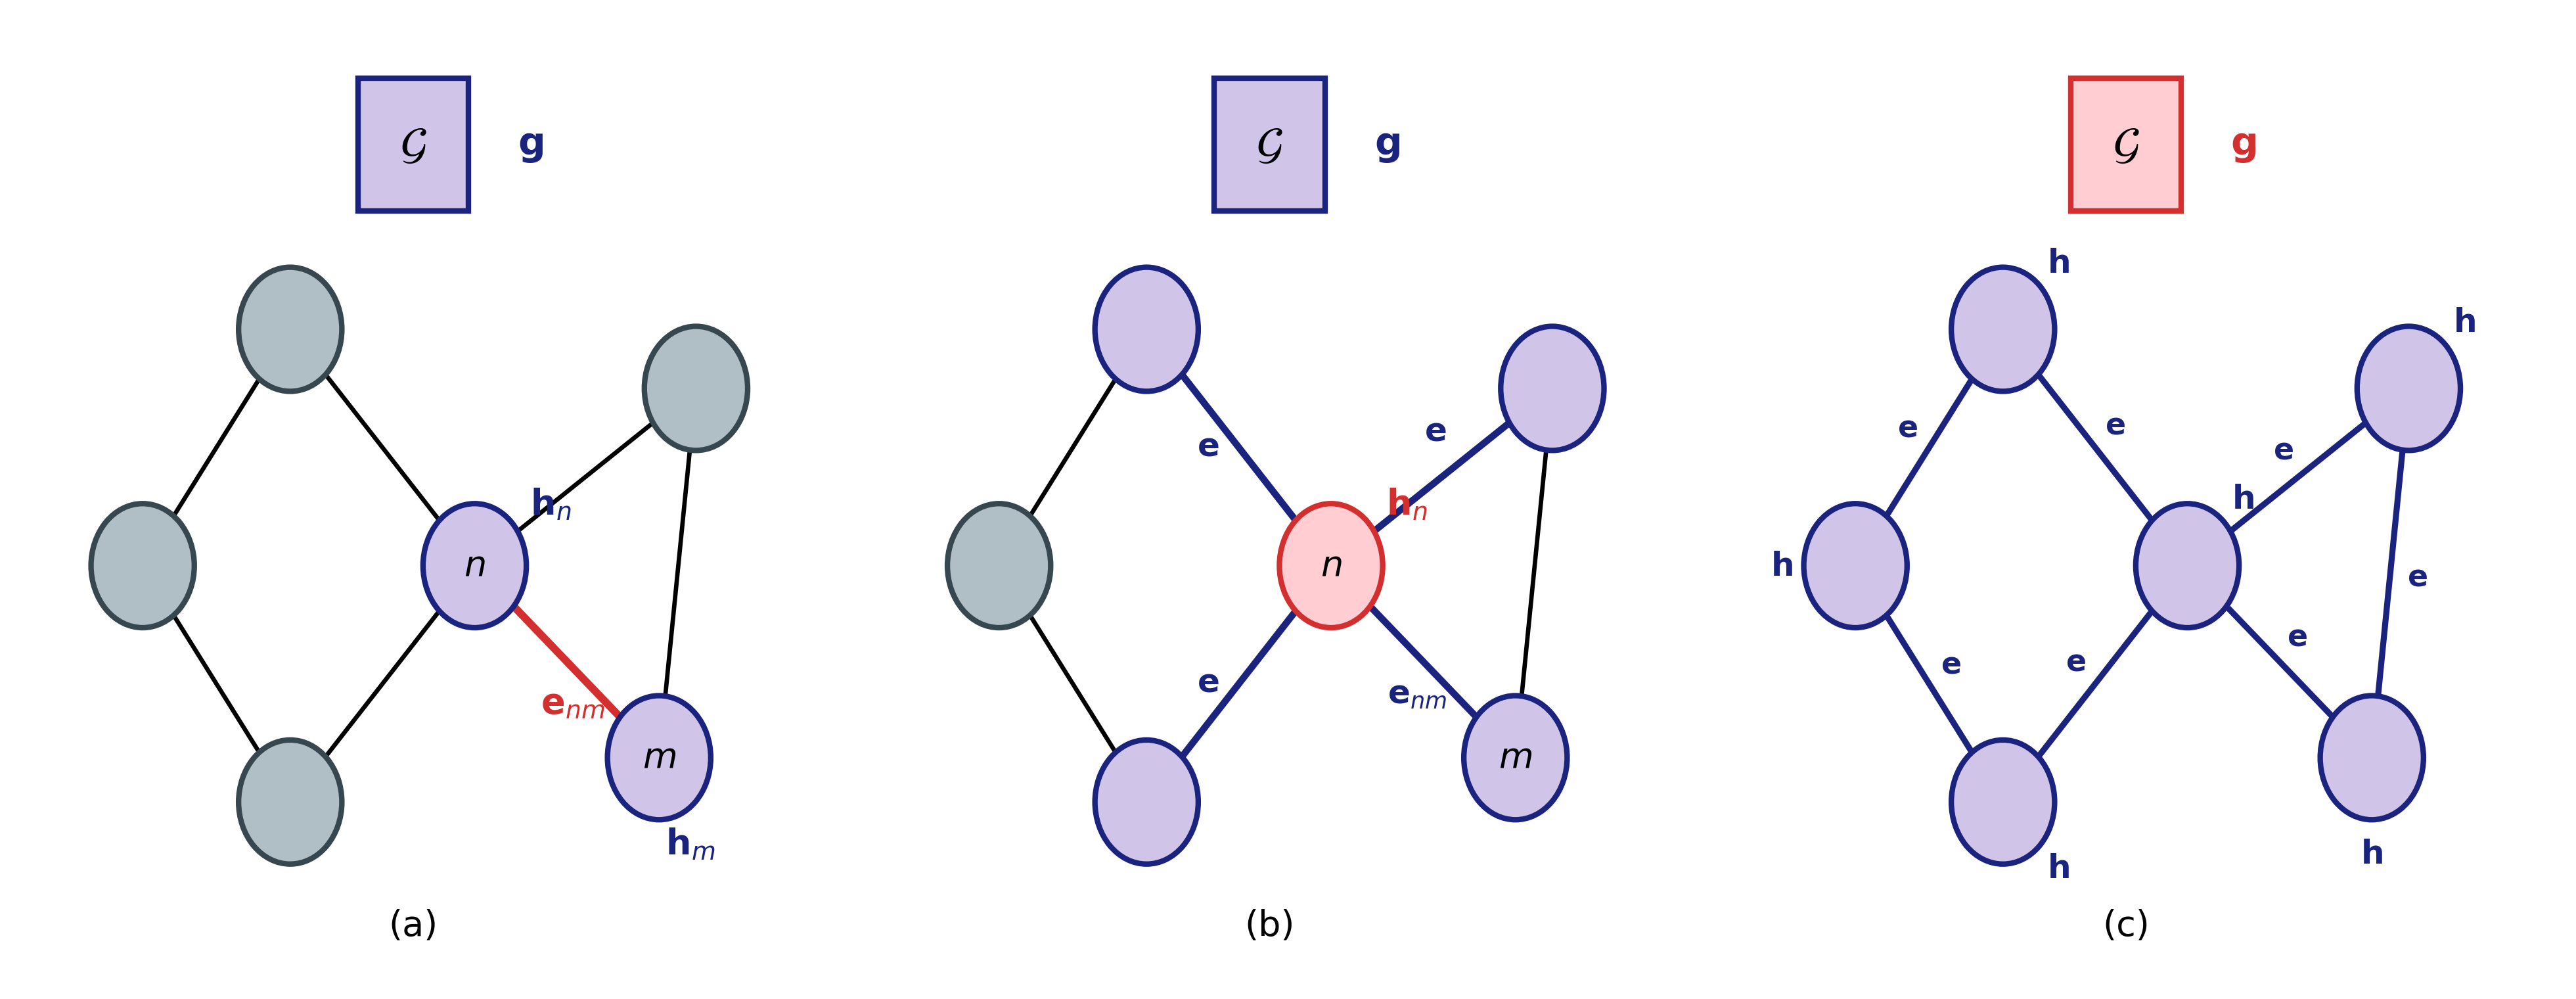

In [4]:
# 教科書 図 13.5 の完全再現
fig13_5 = generate_figure_13_5()
plt.show()


In [5]:
# 一般化 MPNN レイヤー (Algorithm 13.2) の実行
gen_layer = GeneralMPNNLayer(node_dim=6, edge_dim=3, graph_dim=4, seed=10)
g_init = np.array([1.0, 0.0, -1.0, 0.5])

H_gen, E_gen, g_next = gen_layer.forward(graph, X, E_init, g_init)

print("=== Algorithm 13.2 一般化 MPNN の実行結果 ===")
print(f"入力グラフ大域埋め込み: {g_init}")
print(f"更新後グラフ大域埋め込み: {g_next}")
print(f"ノード埋め込み形状: {H_gen.shape}")


=== Algorithm 13.2 一般化 MPNN の実行結果 ===
入力グラフ大域埋め込み: [ 1.   0.  -1.   0.5]
更新後グラフ大域埋め込み: [-0.7498967   0.03917513 -0.14093693 -0.76135841]
ノード埋め込み形状: (4, 6)


---
## 13.3.4 過剰平滑化 (Over-smoothing)

### 1. 理論的課題：深層GNNにおける表現の縮退
メッセージパッシングを多数回反復すると、全ノードの埋め込みが隣接ノードと均一化し、最終的にグラフの連結成分ごとに同一の定数ベクトルへと縮退する現象を**過剰平滑化 (Over-smoothing)** と呼びます。

ノード埋め込みの平滑度は**ディリクレエネルギー (Dirichlet Energy)** で定量化されます：
$$
E(H) = \frac{1}{2} \text{Tr}\left( H^T L_{\text{sym}} H \right)
$$
過剰平滑化が発生すると $E(H) \to 0$ となり、ノードごとの個別性が失われます。

### 2. 緩和手法
1. **残差接続 (Residual Connections)** (式 13.36):
   $$
   \mathbf{h}_n^{(l+1)} = \text{Update}_{\text{node}}\left( \mathbf{h}_n^{(l)}, \mathbf{z}_n^{(l+1)}, \mathbf{g}^{(l)} \right) + \mathbf{h}_n^{(l)} \tag{13.36}
   $$

2. **Jumping Knowledge Networks (JK-Net)** (式 13.37):
   最終層の出力だけでなく、全中間層の表現を結合 (Concatenation) または最大値プーリング (Max-pooling) して読み出し層に送る：
   $$
   \mathbf{y}_n = f\left( \mathbf{h}_n^{(1)} \oplus \mathbf{h}_n^{(2)} \oplus \dots \oplus \mathbf{h}_n^{(L)} \right) \tag{13.37}
   $$


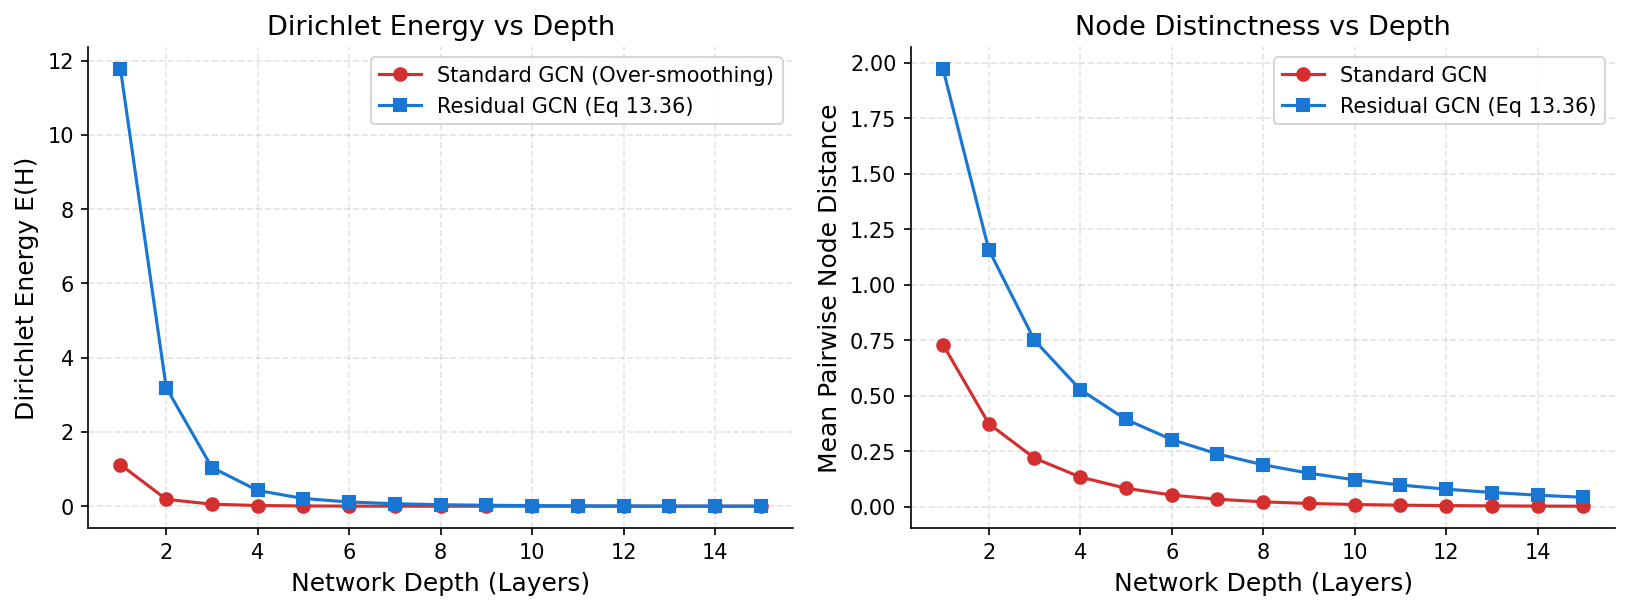

層 15 における標準 GCN ディリクレエネルギー: 2.882454e-06 (縮退)
層 15 における残差 GCN ディリクレエネルギー: 0.001863 (ノード個別性を維持)


In [6]:
# 過剰平滑化のシミュレーション：層の深さとディリクレエネルギー・ノード間距離の推移
N_nodes = 12
edges_ring = [(i, (i + 1) % N_nodes) for i in range(N_nodes)]
# 短絡エッジを追加
edges_ring.extend([(0, 4), (2, 8), (6, 11)])
g_ring = Graph(num_nodes=N_nodes, edges=edges_ring, is_directed=False)

L_sym = g_ring.normalized_laplacian
A_norm = g_ring.renormalized_adjacency

# 初期特徴量
H_init = np.random.RandomState(42).randn(N_nodes, 8)

# 深さ 1 から 15 までの推移を比較
depths = range(1, 16)
energy_standard = []
energy_residual = []
dist_standard = []
dist_residual = []

H_std = H_init.copy()
H_res = H_init.copy()

W = np.eye(8) * 0.8  # 固定重み

for d in depths:
    # 標準 GCN (ReLU(A_norm @ H @ W))
    H_std = relu(A_norm @ H_std @ W)
    # 残差 GCN (0.5 * ReLU(A_norm @ H @ W) + 0.5 * H)
    H_res = 0.5 * relu(A_norm @ H_res @ W) + 0.5 * H_res

    energy_standard.append(compute_dirichlet_energy(H_std, L_sym))
    energy_residual.append(compute_dirichlet_energy(H_res, L_sym))
    dist_standard.append(compute_mean_pairwise_distance(H_std))
    dist_residual.append(compute_mean_pairwise_distance(H_res))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)
ax1.plot(depths, energy_standard, "o-", color="#d32f2f", label="Standard GCN (Over-smoothing)")
ax1.plot(depths, energy_residual, "s-", color="#1976d2", label="Residual GCN (Eq 13.36)")
ax1.set_xlabel("Network Depth (Layers)")
ax1.set_ylabel("Dirichlet Energy E(H)")
ax1.set_title("Dirichlet Energy vs Depth")
ax1.legend()

ax2.plot(depths, dist_standard, "o-", color="#d32f2f", label="Standard GCN")
ax2.plot(depths, dist_residual, "s-", color="#1976d2", label="Residual GCN (Eq 13.36)")
ax2.set_xlabel("Network Depth (Layers)")
ax2.set_ylabel("Mean Pairwise Node Distance")
ax2.set_title("Node Distinctness vs Depth")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"層 15 における標準 GCN ディリクレエネルギー: {energy_standard[-1]:.6e} (縮退)")
print(f"層 15 における残差 GCN ディリクレエネルギー: {energy_residual[-1]:.6f} (ノード個別性を維持)")


---
## 13.3.5 正則化 (Regularization)

グラフ特有の正則化手法として、以下が用いられます：
1. **DropEdge** (Rong et al. 2020): 各順伝播において隣接行列のエッジを確率 $p_{\text{drop}}$ でランダムに間引く。過剰平滑化の防止と汎化性能向上に寄与。
2. **Node Dropout**: ノードの特徴量ベクトルを確率的にゼロマスクする。


In [7]:
# DropEdge と Node Dropout の正則化効果検証
A_orig = g_ring.A.copy()
A_drop = apply_drop_edge(A_orig, p_drop=0.3, seed=42)

print(f"元エッジ数: {int(np.sum(A_orig) / 2)}")
print(f"DropEdge (p=0.3) 適用後エッジ数: {int(np.sum(A_drop) / 2)}")
assert np.sum(A_drop) < np.sum(A_orig), "DropEdge should reduce total edge count"


元エッジ数: 15
DropEdge (p=0.3) 適用後エッジ数: 9


---
## 13.3.6 幾何学的深層学習 (Geometric Deep Learning, EGNN, 式 13.38 〜 13.41)

### 1. 3次元ユークリッド群 $E(3)$ の対称性
分子やタンパク質、物理流体シミュレーションでは、ノードは 3 次元空間座標 $\mathbf{r}_n \in \mathbb{R}^3$ を持ちます。分子の溶解度やエネルギーなどの物理化学的性質は、座標系を任意に**並進 (Translation)、回転 (Rotation)、鏡映 (Reflection)** しても変化しません（$E(3)$ 対称性）。

### 2. $E(n)$ 等変グラフニューラルネットワーク (EGNN, Satorras et al., 2021)
二乗ユークリッド距離 $\|\mathbf{r}_n^{(l)} - \mathbf{r}_m^{(l)}\|^2$ は剛体変換に対して完全に不変です。これを利用して更新方程式を構築します（式 13.38 〜 13.41）：

1. **エッジ更新** (式 13.38):
   $$
   \mathbf{e}_{nm}^{(l+1)} = \text{Update}_{\text{edge}}\left( \mathbf{e}_{nm}^{(l)}, \mathbf{h}_n^{(l)}, \mathbf{h}_m^{(l)}, \|\mathbf{r}_n^{(l)} - \mathbf{r}_m^{(l)}\|^2 \right) \tag{13.38}
   $$

2. **座標更新** (式 13.39):
   $$
   \mathbf{r}_n^{(l+1)} = \mathbf{r}_n^{(l)} + C \sum_{(n, m) \in \mathcal{E}} (\mathbf{r}_n^{(l)} - \mathbf{r}_m^{(l)}) \phi\left( \mathbf{e}_{nm}^{(l+1)} \right) \tag{13.39}
   $$
   ここで差ベクトル $(\mathbf{r}_n - \mathbf{r}_m)$ にスカラ重み $\phi(\mathbf{e}_{nm})$ を乗じることで、回転・並進・鏡映に対する同変性が厳密に保持されます。

3. **ノード集約と特徴量更新** (式 13.40, 13.41):
   $$
   \mathbf{z}_n^{(l+1)} = \text{Aggregate}_{\text{node}}\left( \left\{ \mathbf{e}_{nm}^{(l+1)} : m \in \mathcal{N}(n) \right\} \right) \tag{13.40}
   $$
   $$
   \mathbf{h}_n^{(l+1)} = \text{Update}_{\text{node}}\left( \mathbf{h}_n^{(l)}, \mathbf{z}_n^{(l+1)} \right) \tag{13.41}
   $$


In [8]:
# 3次元 EGNN レイヤーの実行と E(3) 対称性（並進・回転・鏡映）の数値検証
R_coords = np.array([
    [0.0, 0.0, 0.0],
    [1.2, 0.0, 0.0],
    [0.6, 1.0, 0.0],
    [0.6, 0.3, 0.9],
])
H_feats = np.random.RandomState(42).randn(4, 5)
g_egnn = Graph(num_nodes=4, edges=[(0, 1), (1, 2), (2, 0), (0, 3), (1, 3), (2, 3)], is_directed=False)

egnn_layer = EGNNLayer(node_dim=5, edge_dim=3, coord_scale=0.08, seed=42)
report = check_egnn_equivariance(egnn_layer, g_egnn, H_feats, R_coords)

print("=== EGNN (式 13.38 〜 13.41) の幾何学的対称性検証結果 ===")
for test_name, passed in report.items():
    status = "合格 (PASSED)" if passed else "不合格 (FAILED)"
    print(f"  {test_name:35s}: {status}")
    assert passed, f"Geometric symmetry test failed: {test_name}"

print("3次元ユークリッド群 E(3) の完全な同変性・不変性を確認しました。")


=== EGNN (式 13.38 〜 13.41) の幾何学的対称性検証結果 ===
  translation_equivariance           : 合格 (PASSED)
  translation_invariance_features    : 合格 (PASSED)
  rotation_equivariance              : 合格 (PASSED)
  rotation_invariance_features       : 合格 (PASSED)
  reflection_equivariance            : 合格 (PASSED)
  reflection_invariance_features     : 合格 (PASSED)
3次元ユークリッド群 E(3) の完全な同変性・不変性を確認しました。


---
## まとめと第13章演習問題への展開

本ノートブックでは、Bishop (2024) 第13章第13.3節「一般化グラフネットワーク」の全内容を網羅しました：
1. **グラフアテンションネットワーク (13.3.1)**: 双線形・MLPアテンション（式 13.24 〜 13.28）とマルチヘッドGAT。
2. **エッジ埋め込み (13.3.2)**: エッジ隠れ変数の動的更新とノードへの伝播（式 13.29 〜 13.31）。
3. **グラフ埋め込みと統一MPNN (13.3.3)**: ノード・エッジ・大域グラフの4段階同時更新（式 13.32 〜 13.35、Algorithm 13.2、図 13.5）。
4. **過剰平滑化 (13.3.4)**: ディリクレエネルギーによる解析、残差接続（式 13.36）および JK-Net（式 13.37）による緩和。
5. **正則化 (13.3.5)**: DropEdge と Node Dropout による過学習・過剰平滑化抑制。
6. **幾何学的深層学習 (13.3.6)**: 3次元ユークリッド群 $E(3)$ における同変座標更新と分子モデリングへの応用 (EGNN, 式 13.38 〜 13.41)。

これで第13章の本文3節（13.1, 13.2, 13.3）および全図版（Figure 13.1 〜 13.5 全5枚）の実装・検証がすべて完了しました！
次はいよいよ **第13章 演習問題 (Exercises 13.1 〜 13.10, 全10問)** の数理証明と自己採点アサーション検証に進みます。
